In [1]:
import pipeline.calculate_metrics
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gerrychain.grid
import random
from collections import deque
import warnings
random.seed(42)

Fig 4 upper half

In [2]:
def edge_a_ch(rho):
    return (25-50 * rho + 20 * rho ** 2 - 4 * rho ** 3) / (2 * (5 - rho) * (5 - 2 * rho ** 2))

def half_edge_a_ch(rho):
    return (5 - 8 * rho) / (2 * (5 - 5 * rho))

In [3]:
def edge_a_isol(rho):
    return (25 - 41 * rho) / (9 * (5 - rho))

def half_edge_a_isol(rho):
    return (3 - 5 * rho) / (5 - 5 * rho)

In [4]:
def edge_a_const(rho):
    return (1 - rho + rho ** 2) / (2 + rho + rho ** 2)

def half_edge_a_const(rho):
    return .5

In [5]:
def edge_a_one_clust(rho):
    return 1

def half_edge_a_one_clust(rho):
    return 1

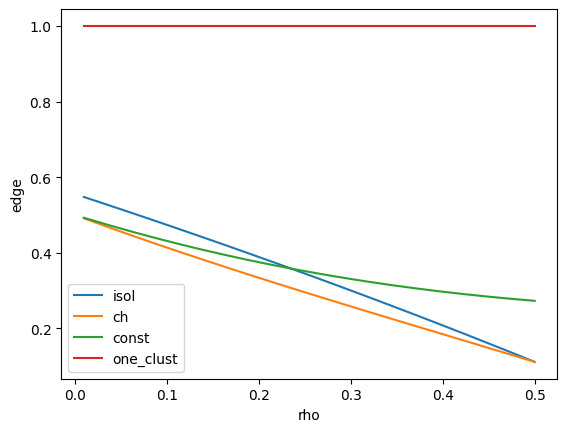

In [6]:
#asymptotic graph for edge
isol = []
ch = []
const = []
one_clust = []

x = np.linspace(.01, .5, 20)

for rho in x:
    isol.append(edge_a_isol(rho))
    ch.append(edge_a_ch(rho))
    const.append(edge_a_const(rho))
    one_clust.append(edge_a_one_clust(rho))

plt.plot(x, isol, label="isol")
plt.plot(x, ch, label="ch")
plt.plot(x, const, label="const")
plt.plot(x, one_clust, label="one_clust")

plt.legend()
plt.xlabel("rho")
plt.ylabel("edge")
plt.show()

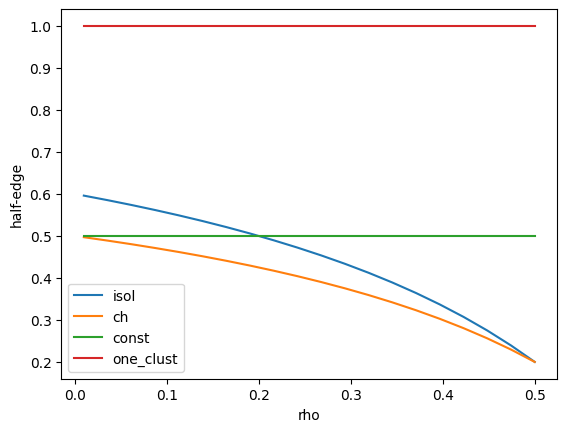

In [7]:
#asymptotic graph for half edge

isol = []
ch = []
const = []
one_clust = []

x = np.linspace(.01, .5, 20)

for rho in x:
    isol.append(half_edge_a_isol(rho))
    ch.append(half_edge_a_ch(rho))
    const.append(half_edge_a_const(rho))
    one_clust.append(half_edge_a_one_clust(rho))

plt.plot(x, isol, label="isol")
plt.plot(x, ch, label="ch")
plt.plot(x, const, label="const")
plt.plot(x, one_clust, label="one_clust")

plt.legend()
plt.xlabel("rho")
plt.ylabel("half-edge")
plt.show()

Fig 4 Lower Half

In [8]:
def populate_ch_grid(G, rho, M, eps): #give graph x and y pop'scripts
    for node in G.graph.nodes:
        if G.graph.nodes[node]["sum"] % 2 == 0:
            if eps == True:
                e = random.randint(-5, 5)
                G.graph.nodes[node]["x_pop"] = 0 + e
                G.graph.nodes[node]["y_pop"] = M + e
            else:
                G.graph.nodes[node]["x_pop"] = 0
                G.graph.nodes[node]["y_pop"] = M
        else:
            if eps == True:
                e = random.uniform(-5, 5)
                G.graph.nodes[node]["x_pop"] = 2 * M * rho + e
                G.graph.nodes[node]["y_pop"] = M * (1 - 2* rho) + e
            else:
                G.graph.nodes[node]["x_pop"] = 2 * M * rho
                G.graph.nodes[node]["y_pop"] = M * (1 - 2* rho)
    return G #should probably be returning G.graph

In [9]:
def generate_ch_grid(n: int, m: int, rho, M, eps = False):
    G = gerrychain.grid.Grid((n, m))
    for node in G.graph.nodes:
        G.graph.nodes[node]["x"] = node[0]
        G.graph.nodes[node]["y"] = node[1]
        G.graph.nodes[node]["sum"] = node[0] + node[1]
    if eps == True:
        G = populate_ch_grid(G, rho, M, eps = True)
    else:
        G = populate_ch_grid(G, rho, M, eps = False)
    return G

In [10]:
def populate_const_grid(G, rho, M):
    for node in G.graph.nodes:
        G.graph.nodes[node]["x_pop"] = rho * M
        G.graph.nodes[node]["y_pop"] = (1 - rho) * M
    return G

In [11]:
def generate_const_grid(n, m, rho, M):
    G = gerrychain.grid.Grid((n, m))
    for node in G.graph.nodes:
        G.graph.nodes[node]["x"] = node[0]
        G.graph.nodes[node]["y"] = node[1]
        G.graph.nodes[node]["sum"] = node[0] + node[1]
    G = populate_const_grid(G, rho, M)
    return G

In [12]:
def populate_cluster_bfs(start_node, G, M, tot_x_pop):
    # queue for BFS
    queue = deque([start_node])

    visited = set()
    x_pop_sum = 0

    while queue and x_pop_sum < tot_x_pop:
        node = queue.popleft()

        if node in visited:
            continue
        visited.add(node)

        # assign values
        G.graph.nodes[node]["x_pop"] = M
        G.graph.nodes[node]["y_pop"] = 0

        x_pop_sum += M

        # add neighbors (randomized expansion)
        neighbors = list(G.graph.neighbors(node))
        random.shuffle(neighbors)

        for nbr in neighbors:
            if nbr not in visited:
                queue.append(nbr)

    return G

In [13]:
def generate_clust_grid(n, m, rho, M):
    G = gerrychain.grid.Grid((n, m))
    for node in G.graph.nodes:
        G.graph.nodes[node]["x"] = node[0]
        G.graph.nodes[node]["y"] = node[1]
        G.graph.nodes[node]["x_pop"] = 0
        G.graph.nodes[node]["y_pop"] = 0
    x_rand = random.randint(0 , n-1)
    y_rand = random.randint(0 , m-1)
    tot_pop = n * m * M
    tot_x_pop = tot_pop * rho
    start_node = (x_rand, y_rand)    
    G = populate_cluster_bfs(start_node, G, M, tot_x_pop)
    for node in G.graph.nodes():
        if G.graph.nodes[node]["x_pop"] == 0:
            G.graph.nodes[node]["y_pop"] = M
    return G

In [14]:
def generate_2clust_grid(n, m, rho, M):
    G = gerrychain.grid.Grid((n, m))
    for node in G.graph.nodes:
        G.graph.nodes[node]["x"] = node[0]
        G.graph.nodes[node]["y"] = node[1]
        G.graph.nodes[node]["x_pop"] = 0
        G.graph.nodes[node]["y_pop"] = 0
    x_rand = random.randint(0 , int(n / 2) - 1)
    y_rand = random.randint(0 , int(m / 2) - 1)
    x_rand2 = random.randint(int(n / 2)  , n - 1)
    y_rand2 = random.randint(int(m / 2), m - 1)
    tot_pop = n * m * M
    tot_x_pop = tot_pop * rho * .5
    start_node = (x_rand, y_rand)    
    start_node_2 = (x_rand2, y_rand2)
    G = populate_cluster_bfs(start_node, G, M, tot_x_pop)
    G = populate_cluster_bfs(start_node_2, G, M, tot_x_pop)

    for node in G.graph.nodes():
        if G.graph.nodes[node]["x_pop"] == 0:
            G.graph.nodes[node]["y_pop"] = M
    return G

In [15]:
def populate_isol(G, M, tot_x_pop):
    target = tot_x_pop / M

    nodes = list(G.graph.nodes)
    random.shuffle(nodes)

    forbidden = set()
    selected = 0

    for node in nodes:
        if selected >= target:
            break

        if node in forbidden:
            continue

        G.graph.nodes[node]["x_pop"] = M
        G.graph.nodes[node]["y_pop"] = 0
        selected += 1

        forbidden.add(node)
        forbidden.update(G.graph.neighbors(node))

    return G      

In [16]:
def generate_isol_grid(n, m, rho, M):
    G = gerrychain.grid.Grid((n, m))
    for node in G.graph.nodes:
        G.graph.nodes[node]["x"] = node[0]
        G.graph.nodes[node]["y"] = node[1]
        G.graph.nodes[node]["x_pop"] = 0
        G.graph.nodes[node]["y_pop"] = 0
    tot_pop = n * m * M
    tot_x_pop = tot_pop * rho
    x_rand = random.randint(0 , n-1)
    y_rand = random.randint(0 , m-1)
    start_node = (x_rand, y_rand)    
    G = populate_isol(G, M, tot_x_pop)
    for node in G.graph.nodes():
        if G.graph.nodes[node]["x_pop"] == 0:
            G.graph.nodes[node]["y_pop"] = M
    return G

In [17]:
def generate_isol_grid_2(n, m, rho, M):
    G = generate_ch_grid(n, m, .5, M)
    nodes = list(G.graph.nodes)
    random.shuffle(nodes)
    current_x_pop = n * m * M * .5
    target_x_pop = n * m * M * rho

    for node in nodes:
        if current_x_pop <= target_x_pop:
            break
        if G.graph.nodes[node]["y_pop"] == 0:
            G.graph.nodes[node]["x_pop"] = 0
            G.graph.nodes[node]["y_pop"] = M
            current_x_pop = current_x_pop - M
    return G

In [18]:
graphs_ch = []
graphs_const = []
graphs_clust = [] 
graphs_2clust = [] 
graphs_isol = []


rhos = np.linspace(.1, .5, 5)

for rho in rhos: 
    graphs_ch.append(generate_ch_grid(90, 90, rho, 1000))
    graphs_const.append(generate_const_grid(90, 90, rho, 1000))
    graphs_clust.append(generate_clust_grid(90, 90, rho, 1000))
    graphs_2clust.append(generate_2clust_grid(90, 90, rho, 1000))
    graphs_isol.append(generate_isol_grid_2(90, 90, rho, 1000))


edge_ch = [pipeline.calculate_metrics.edge(G.graph, "x_pop", "y_pop") for G in graphs_ch]
half_edge_ch = [pipeline.calculate_metrics.half_edge(G.graph, "x_pop", "y_pop") for G in graphs_ch]
edge_const = [pipeline.calculate_metrics.edge(G.graph, "x_pop", "y_pop") for G in graphs_const]
half_edge_const = [pipeline.calculate_metrics.half_edge(G.graph, "x_pop", "y_pop") for G in graphs_const]
edge_clust = [pipeline.calculate_metrics.edge(G.graph, "x_pop", "y_pop") for G in graphs_clust]
half_edge_clust = [pipeline.calculate_metrics.half_edge(G.graph, "x_pop", "y_pop") for G in graphs_clust]
edge_2clust = [pipeline.calculate_metrics.edge(G.graph, "x_pop", "y_pop") for G in graphs_2clust]
half_edge_2clust = [pipeline.calculate_metrics.half_edge(G.graph, "x_pop", "y_pop") for G in graphs_2clust]
edge_isol = [pipeline.calculate_metrics.edge(G.graph, "x_pop", "y_pop") for G in graphs_isol]
half_edge_isol = [pipeline.calculate_metrics.half_edge(G.graph, "x_pop", "y_pop") for G in graphs_isol]

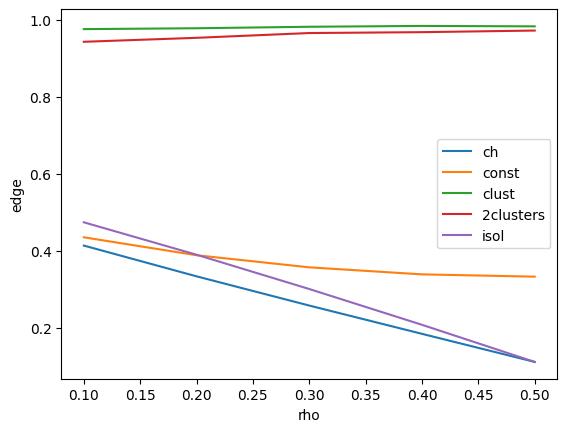

In [19]:
plt.plot(rhos, edge_ch, label="ch")
plt.plot(rhos, edge_const, label="const")
plt.plot(rhos, edge_clust, label="clust")
plt.plot(rhos, edge_2clust, label="2clusters")
plt.plot(rhos, edge_isol, label="isol")

plt.legend()
plt.xlabel("rho")
plt.ylabel("edge")
plt.show()

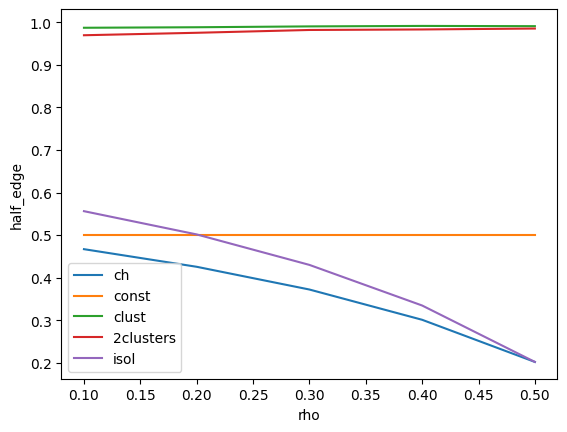

In [20]:
plt.plot(rhos, half_edge_ch, label="ch")
plt.plot(rhos, half_edge_const, label="const")
plt.plot(rhos, half_edge_clust, label="clust")
plt.plot(rhos, half_edge_2clust, label="2clusters")
plt.plot(rhos, half_edge_isol, label="isol")

plt.legend()
plt.xlabel("rho")
plt.ylabel("half_edge")
plt.show()

In [21]:
np.linspace(0, 1, 20)

array([0.        , 0.05263158, 0.10526316, 0.15789474, 0.21052632,
       0.26315789, 0.31578947, 0.36842105, 0.42105263, 0.47368421,
       0.52631579, 0.57894737, 0.63157895, 0.68421053, 0.73684211,
       0.78947368, 0.84210526, 0.89473684, 0.94736842, 1.        ])

Fig 5

In [22]:
def draw_grid(G, lab):
    nodelist = list(G.graph.nodes())
    pos = {
        node: (
            G.graph.nodes[node]["x"],
            G.graph.nodes[node]["y"]
        )
        for node in nodelist
        }
    colors = [
        "red" if G.graph.nodes[node]["x_pop"] != 0 else "blue"
        for node in nodelist
        ]
    labels = {node: G.graph.nodes[node]["x_pop"] for node in nodelist}
    nx.draw(
        G.graph,
        node_size=5,
        pos=pos,
        nodelist = nodelist,
        node_color = colors,
        labels = labels,
        with_labels=lab
        )
    plt.show()


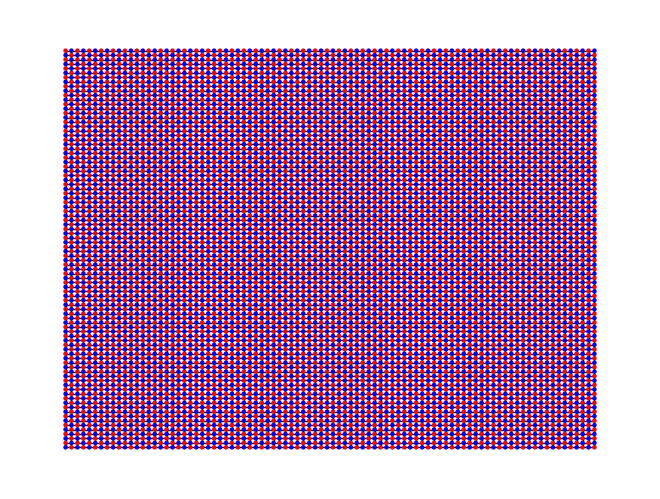

In [23]:
draw_grid(generate_ch_grid(90, 90, .4, 1000), False)

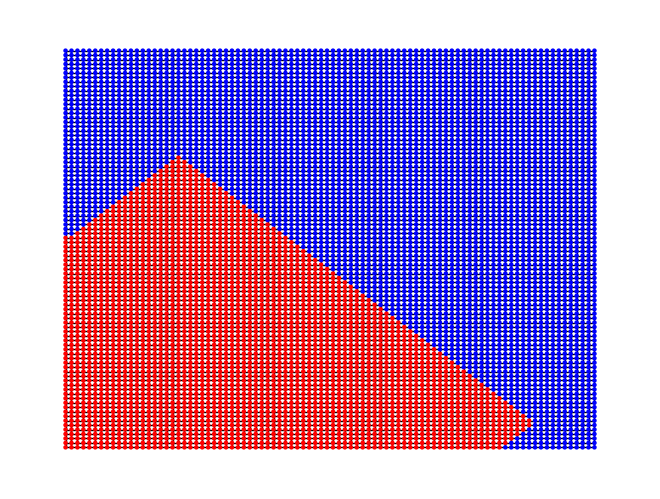

In [24]:
draw_grid(generate_clust_grid(90, 90, .4, 1000), False)

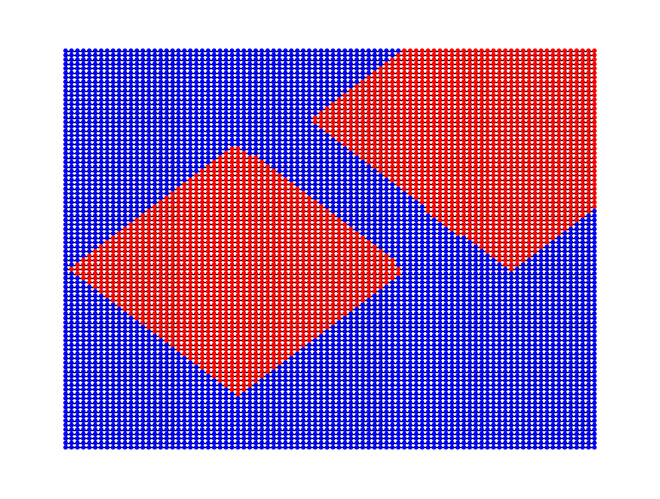

In [25]:
draw_grid(generate_2clust_grid(90, 90, .4, 1000), False)

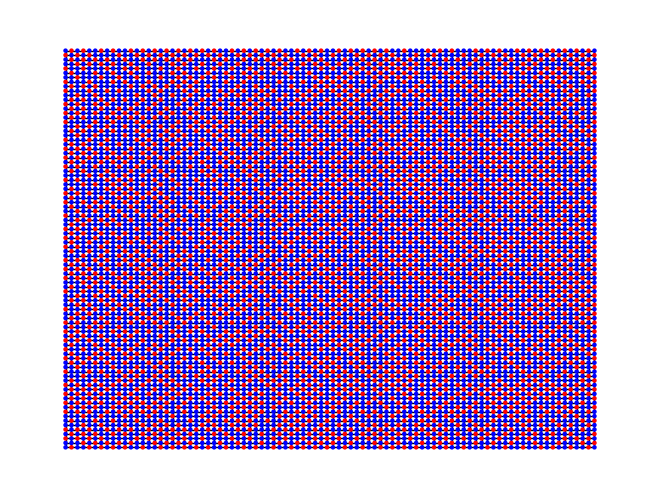

In [26]:
draw_grid(generate_isol_grid(90, 90, .4, 1000), False)

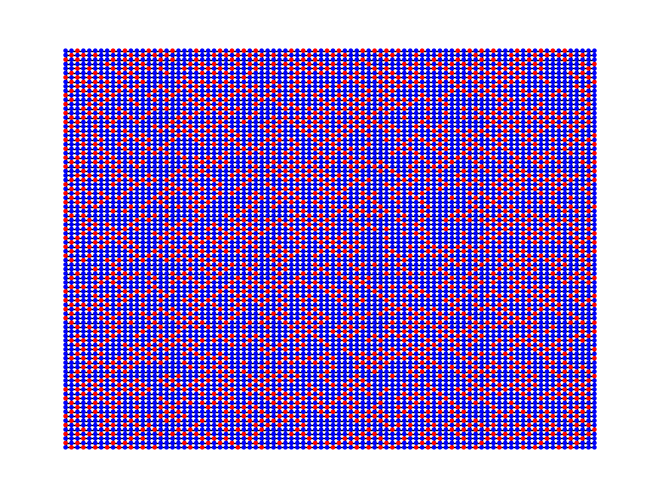

In [27]:
draw_grid(generate_isol_grid_2(90, 90, .3, 1000), False)

Fig. 13

In [28]:
def collapse_grid(G, m):
    G_collapse = generate_ch_grid(int(m/2), int(m/2), 0, 0, eps = False)
    for node in G_collapse.graph.nodes:
        G_collapse.graph.nodes[node]["x_pop"] = 0 
        G_collapse.graph.nodes[node]["y_pop"] = 0
    for i, j in G.graph.nodes:
        x_new = i // 2
        y_new = j // 2
        G_collapse.graph.nodes[(x_new, y_new)]["x_pop"] += G.graph.nodes[(i, j)]["x_pop"]
        G_collapse.graph.nodes[(x_new, y_new)]["y_pop"] += G.graph.nodes[(i, j)]["y_pop"]
    return G_collapse

In [29]:
def totals(G):
    for node in G.graph.nodes():
        G.graph.nodes[node]["total_pop"] = G.graph.nodes[node]["x_pop"] +  G.graph.nodes[node]["y_pop"]
    return G

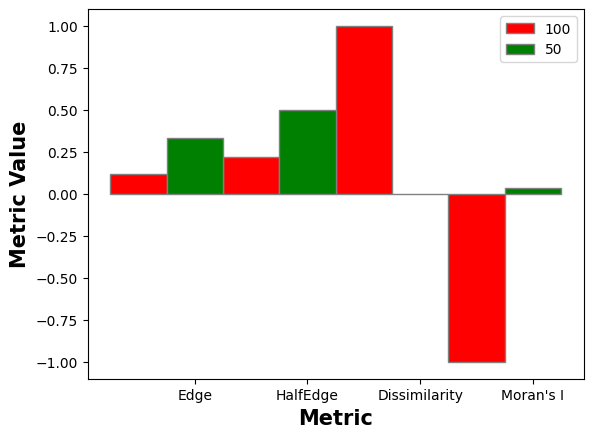

In [30]:
G = generate_ch_grid(10, 10, .5, 1000, eps = True)
G_2 = collapse_grid(G, 10)
metrics= ["Edge", "HalfEdge", "Dissimilarity", "Moran's I"]
scores_100 = [pipeline.calculate_metrics.edge(G.graph, "x_pop", "y_pop"),
          pipeline.calculate_metrics.half_edge(G.graph, "x_pop", "y_pop"),
          pipeline.calculate_metrics.dissimilarity(totals(G).graph, "x_pop", "total_pop"),
          pipeline.calculate_metrics.moran(G.graph, "x_pop", "y_pop")]
scores_50 = [pipeline.calculate_metrics.edge(G_2.graph, "x_pop", "y_pop"),
          pipeline.calculate_metrics.half_edge(G_2.graph, "x_pop", "y_pop"),
          pipeline.calculate_metrics.dissimilarity(totals(G_2).graph, "x_pop", "total_pop"),
          pipeline.calculate_metrics.moran(G_2.graph, "x_pop", "y_pop")]

barWidth = 0.5
br1 = np.arange(len(scores_100)) 
br2 = [x + barWidth for x in br1]

plt.bar(br1, scores_100, color ='r', width = barWidth, 
        edgecolor ='grey', label ='100') 
plt.bar(br2, scores_50, color ='g', width = barWidth, 
        edgecolor ='grey', label ='50') 

plt.xlabel('Metric', fontweight ='bold', fontsize = 15) 
plt.ylabel('Metric Value', fontweight ='bold', fontsize = 15) 
plt.xticks([r + barWidth for r in range(len(scores_100))], metrics)

plt.legend()
plt.show()

Fig. 14

In [32]:
def corner_clust(n, m, M):
    G = generate_const_grid(100, 100, 0, M)
    start_node = 0, 0
    for i in range(0, n):
        for j in range (0, m):
            G.graph.nodes[(i,j)]["x_pop"] = M
            G.graph.nodes[(i,j)]["y_pop"] = 0
    return G

In [33]:
def random_corner_clust(n, m, M):
    G = generate_const_grid(100, 100, 0, M)
    start_node = 0, 0
    for i in range(0, n):
        for j in range (0, m):
            epsilon = random.randint(-5, 5)
            G.graph.nodes[(i,j)]["x_pop"] = M + epsilon
            G.graph.nodes[(i,j)]["y_pop"] = 0 
    for node in G.graph.nodes():
        if G.graph.nodes[node]["y_pop"] == M:
            epsilon = random.randint(-5, 5)
            G.graph.nodes[node]["y_pop"] = M + epsilon
    
    return G

In [34]:
def poc_share(G):
    tot_x = 0
    tot_y = 0
    for node in G.graph.nodes():
        tot_x += G.graph.nodes[node]["x_pop"]
        tot_y += G.graph.nodes[node]["y_pop"]
    tot_pop = tot_x + tot_y
    return tot_x / tot_pop


In [35]:

rhos = []
graphs = []
dims = [(20, 25), (25, 40), (30, 50), (40, 50), 
        (50, 50), (50, 60), (50, 70), (50, 80), 
        (60, 75), (50, 100)]

edge = []
half_edge = []
diss = []
moran = []

for i, j in dims:
    G = corner_clust(i, j, 1)
    graphs.append(G)
    rhos.append(poc_share(G))

rhos.sort()

for graph in graphs:
    edge.append(pipeline.calculate_metrics.edge(graph.graph, "x_pop", "y_pop"))
    half_edge.append(pipeline.calculate_metrics.half_edge(graph.graph, "x_pop", "y_pop"))
    diss.append(pipeline.calculate_metrics.dissimilarity(totals(graph).graph, "x_pop", "total_pop"))
    moran.append(pipeline.calculate_metrics.moran(graph.graph, "x_pop", "y_pop"))


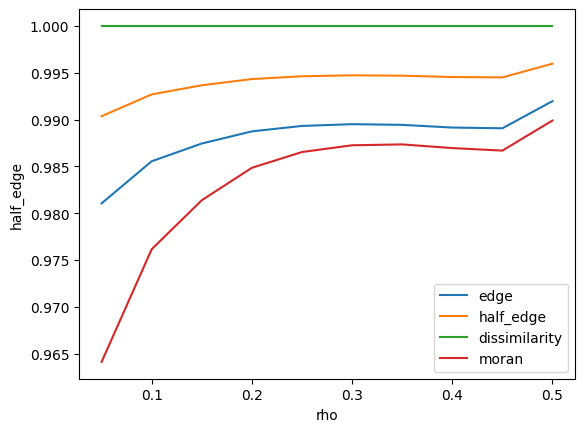

In [36]:
plt.plot(rhos, edge, label="edge")
plt.plot(rhos, half_edge, label="half_edge")
plt.plot(rhos, diss, label="dissimilarity")
plt.plot(rhos, moran, label="moran")

plt.legend()
plt.xlabel("rho")
plt.ylabel("half_edge")
plt.show()

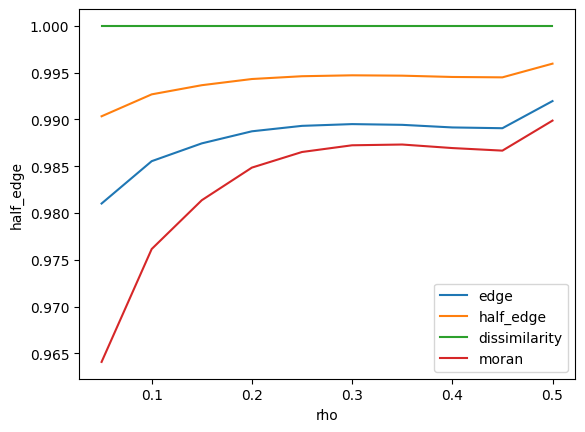

In [37]:

rhos = []
graphs = []
dims = [(20, 25), (25, 40), (30, 50), (40, 50), 
        (50, 50), (50, 60), (50, 70), (50, 80), 
        (60, 75), (50, 100)]

edge = []
half_edge = []
diss = []
moran = []

for i, j in dims:
    G = random_corner_clust(i, j, 1000)
    graphs.append(G)
    rhos.append(poc_share(G))

rhos.sort()

for graph in graphs:
    edge.append(pipeline.calculate_metrics.edge(graph.graph, "x_pop", "y_pop"))
    half_edge.append(pipeline.calculate_metrics.half_edge(graph.graph, "x_pop", "y_pop"))
    diss.append(pipeline.calculate_metrics.dissimilarity(totals(graph).graph, "x_pop", "total_pop"))
    moran.append(pipeline.calculate_metrics.moran(graph.graph, "x_pop", "y_pop"))

plt.plot(rhos, edge, label="edge")
plt.plot(rhos, half_edge, label="half_edge")
plt.plot(rhos, diss, label="dissimilarity")
plt.plot(rhos, moran, label="moran")

plt.legend()
plt.xlabel("rho")
plt.ylabel("half_edge")
plt.show()


In [38]:
def half_pos_unif(rhos, M):
    graphs = []
    for rho in rhos:
        G = generate_const_grid(100, 100, rho, M)
        graphs.append(G)

    for j in range (0, 100):   
        for i in range(0, 50):
            epsilon = random.randint(0, 5)
            for n, rho in enumerate(rhos):
                graphs[n].graph.nodes[(i,j)]["x_pop"] = rho * epsilon + graphs[n].graph.nodes[(i,j)]["x_pop"]
                graphs[n].graph.nodes[(i,j)]["y_pop"] = (1-rho) * epsilon + graphs[n].graph.nodes[(i,j)]["y_pop"]
        for i in range(50, 100):
            epsilon = random.randint(-5, 0)
            for n, rho in enumerate(rhos):
                graphs[n].graph.nodes[(i,j)]["x_pop"] = rho * epsilon + graphs[n].graph.nodes[(i,j)]["x_pop"]
                graphs[n].graph.nodes[(i,j)]["y_pop"] = (1-rho) * epsilon + graphs[n].graph.nodes[(i,j)]["y_pop"]
    return graphs

In [39]:
rhos = [.1, .2, .3, .4, .5]
graphs = half_pos_unif(rhos, 1000)

edge = []
half_edge = []
diss = []
moran = []

for graph in graphs:
    edge.append(pipeline.calculate_metrics.edge(graph.graph, "x_pop", "y_pop"))
    half_edge.append(pipeline.calculate_metrics.half_edge(graph.graph, "x_pop", "y_pop"))
    diss.append(pipeline.calculate_metrics.dissimilarity(totals(graph).graph, "x_pop", "total_pop"))
    moran.append(pipeline.calculate_metrics.moran(graph.graph, "x_pop", "y_pop"))

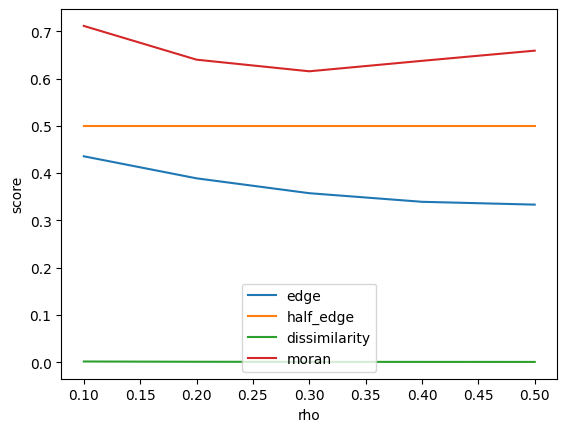

In [40]:
plt.plot(rhos, edge, label="edge")
plt.plot(rhos, half_edge, label="half_edge")
plt.plot(rhos, diss, label="dissimilarity")
plt.plot(rhos, moran, label="moran")

plt.legend()
plt.xlabel("rho")
plt.ylabel("score")
plt.show()

In [41]:
def random_unif(rhos, M):
    graphs = []
    for rho in rhos:
        G = generate_const_grid(100, 100, rho, M)
        graphs.append(G)

    for j in range (0, 100):   
        for i in range(0, 100):
            epsilon = random.randint(-5, 5)
            for n, rho in enumerate(rhos):
                graphs[n].graph.nodes[(i,j)]["x_pop"] = rho * epsilon + graphs[n].graph.nodes[(i,j)]["x_pop"]
                graphs[n].graph.nodes[(i,j)]["y_pop"] = (1-rho) * epsilon + graphs[n].graph.nodes[(i,j)]["y_pop"]
    return graphs

In [42]:
rhos = [.1, .2, .3, .4, .5]
graphs = random_unif(rhos, 1000)

edge = []
half_edge = []
diss = []
moran = []

for graph in graphs:
    edge.append(pipeline.calculate_metrics.edge(graph.graph, "x_pop", "y_pop"))
    half_edge.append(pipeline.calculate_metrics.half_edge(graph.graph, "x_pop", "y_pop"))
    diss.append(pipeline.calculate_metrics.dissimilarity(totals(graph).graph, "x_pop", "total_pop"))
    moran.append(pipeline.calculate_metrics.moran(graph.graph, "x_pop", "y_pop"))

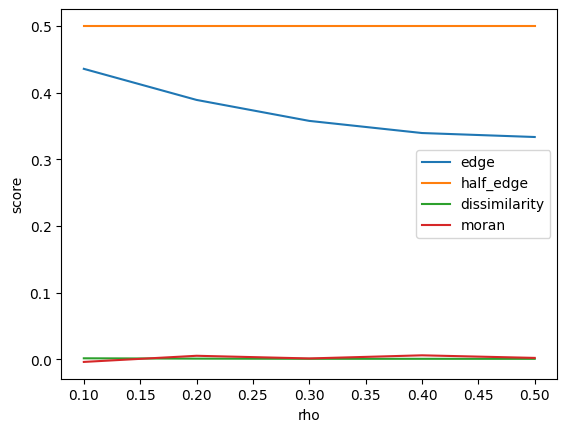

In [43]:
plt.plot(rhos, edge, label="edge")
plt.plot(rhos, half_edge, label="half_edge")
plt.plot(rhos, diss, label="dissimilarity")
plt.plot(rhos, moran, label="moran")

plt.legend()
plt.xlabel("rho")
plt.ylabel("score")
plt.show()